# Proyecto 1: plantilla de entrega

**Ciencia de Datos, Sección A** · Sesión 12 · 1 de septiembre de 2026

Entrega: **viernes 11 de septiembre** · 10 puntos

---

Esta es la plantilla del Proyecto 1: las secciones ya están creadas y las celdas de código están vacías. Trabajen encima de este archivo, renómbrenlo como `P1-<su apellido>.ipynb` y borren las instrucciones en cursiva antes de entregar.

**Autor(es): Juan David Contreras**

**Dataset elegido: Football Players Datasets 2015-2024 (Kaggle) — estadísticas de jugadores de élite (goles, asistencias, partidos, rating) por temporada**

### Rúbrica resumida

| Criterio | Pts | Qué buscamos |
|---|---|---|
| Pregunta y datos | 2 | Pregunta clara, provenance del dataset |
| EDA | 3 | Hallazgos, no galería de gráficas |
| Features | 2 | Cada decisión justificada, sin leakage |
| Baseline | 2 | Validación correcta, métrica adecuada |
| Límites | 1 | Qué no puede concluirse con estos datos |

## 1. Pregunta y contexto

Los jugadores de fútbol de élite pueden tener carreras con altibajos, pasar de una gran temporada a una muy floja. Este proyecto busca responder si es posible anticipar esos altibajos usando solo información ya disponible al cierre de una temporada actual.

La respuesta sería útil para cuerpos técnicos u ojeadores que evalúan renovaciones o posibles fichajes, para plataformas de fantasy football que arman proyecciones, y para periodismo deportivo que especula sobre el rendimiento futuro de una estrella. Si el modelo dijera que un jugador va a caer en rendimiento, eso podría influir en decisiones como no ofrecer una renovación larga o pedir un precio de venta más bajo; si dijera que va a mantenerse o mejorar, podría justificar lo contrario.

**Pregunta:** ¿Se puede predecir cuántos goles anotará un jugador de fútbol de élite en su próxima temporada, a partir de sus estadísticas (partidos jugados, goles, asistencias y rating) en la temporada actual?

**Tipo de problema:** Regresión

**Variable objetivo:** `Goals_next` — los goles del jugador en la temporada inmediatamente siguiente


## 2. Los datos

- **Fuente:** Kaggle — *"Football Players Datasets 2015-2024"*, subido por el usuario abdulmalik1518
- **URL:** https://www.kaggle.com/datasets/abdulmalik1518/football-players-datasets-2015-2024
- **Fecha de descarga:** *07-09-2026*
- **Licencia:** *Apache 2.0*
- **Unidad de observación:** cada fila representa a un jugador con dos temporadas consecutivas ya emparejadas: sus estadísticas en la temporada N (features) y sus goles en la temporada N+1 (target, `Goals_next`).

**Diccionario de variables usadas:**

| Variable | Significado |
|---|---|
| `Matches` | Partidos jugados en la temporada N |
| `Goals` | Goles anotados en la temporada N |
| `Assists` | Asistencias en la temporada N |
| `Seasons Ratings` | Calificación promedio de la temporada N |
| `cambio_equipo` | 'Si'/'No': si el jugador jugó para un club distinto en la temporada N+1 |
| `Goals_next` | Goles anotados en la temporada N+1 (**target**) |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

# Cargar el dataset donde una fila es igual a un jugador en una temporada
raw = pd.read_csv('Latest_Football__Players_2024_Data.csv')
raw = raw.drop_duplicates()  # había filas repetidas exactas

# Año de inicio de la temporada, para poder ordenar cronológicamente
raw['anio'] = raw['Seasons'].str[:4].astype(int)
raw = raw.sort_values(['Players', 'anio']).reset_index(drop=True)

# La pregunta es: En base a la temporada N, predecir los goles de la N+1

raw['Goals_next'] = raw.groupby('Players')['Goals'].shift(-1)
raw['anio_next'] = raw.groupby('Players')['anio'].shift(-1)
raw['Team_next'] = raw.groupby('Players')['Teams'].shift(-1)

# Nos quedamos solo con pares de temporadas consecutivas (N -> N+1)
df = raw[raw['anio_next'] == raw['anio'] + 1].copy()
df['cambio_equipo'] = np.where(df['Teams'] == df['Team_next'], 'No', 'Si')

df = df[['Players', 'Matches', 'Goals', 'Assists', 'Seasons Ratings',
         'cambio_equipo', 'Goals_next']].reset_index(drop=True)
df.head()

,Players,Matches,Goals,Assists,Seasons Ratings,cambio_equipo,Goals_next
0,Adrien Rabiot,39,4,4,7.4,No,5.0
1,Adrien Rabiot,50,5,7,7.1,No,2.0
2,Adrien Rabiot,20,2,2,7.4,Si,1.0
3,Adrien Rabiot,37,1,1,6.9,No,5.0
4,Adrien Rabiot,47,5,3,7.2,No,0.0


## 3. Primer barrido

*Forma, tipos, y una mirada rápida a las categóricas. Escriban debajo qué les llamó la atención.*

In [2]:
print(df.shape)
df.info()
df.head()

(1038, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Players          1038 non-null   object 
 1   Matches          1038 non-null   int64  
 2   Goals            1038 non-null   int64  
 3   Assists          1038 non-null   int64  
 4   Seasons Ratings  1038 non-null   float64
 5   cambio_equipo    1038 non-null   object 
 6   Goals_next       1038 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 56.9+ KB


,Players,Matches,Goals,Assists,Seasons Ratings,cambio_equipo,Goals_next
0,Adrien Rabiot,39,4,4,7.4,No,5.0
1,Adrien Rabiot,50,5,7,7.1,No,2.0
2,Adrien Rabiot,20,2,2,7.4,Si,1.0
3,Adrien Rabiot,37,1,1,6.9,No,5.0
4,Adrien Rabiot,47,5,3,7.2,No,0.0


In [3]:
print(df.describe())
print(df['cambio_equipo'].value_counts())

           Matches        Goals      Assists  Seasons Ratings   Goals_next
count  1038.000000  1038.000000  1038.000000      1038.000000  1038.000000
mean     36.930636     8.117534     4.798651         7.104721     8.254335
std      11.803805     9.451376     4.559149         0.416079     9.315061
min       1.000000     0.000000     0.000000         5.100000     0.000000
25%      31.000000     2.000000     1.000000         6.900000     2.000000
50%      39.000000     4.000000     4.000000         7.100000     5.000000
75%      46.000000    12.000000     7.000000         7.300000    12.000000
max      59.000000    55.000000    25.000000         8.900000    55.000000
cambio_equipo
No    789
Si    249
Name: count, dtype: int64


**Observaciones del primer barrido:**

1. Tras exigir temporadas consecutivas, el dataset de pares quedó con 1038 filas y 165 jugadores únicos (de los 167 originales) — se perdieron los pares donde había un hueco de más de un año entre dos temporadas registradas del mismo jugador(osea, quienes no jugaron por un año).
2. `Goals` y `Goals_next` tienen una dispersión enorme: la mediana es de apenas 4-5 goles por temporada, pero el máximo llega a 55 — son las mismas superestrellas (Messi, Cristiano, Lewandowski, Haaland) empujando la cola derecha de la distribución.
3. El dataset está desbalanceado en `cambio_equipo`: 789 pares (76%) son jugadores que se quedaron en el mismo club la temporada siguiente, contra solo 249 (24%) que cambiaron de equipo.


## 4. Calidad de datos

*Faltantes (y su mecanismo: MCAR, MAR o MNAR, con argumento), duplicados y outliers. Para cada problema: qué hicieron y por qué. Un `dropna()` sin comentario cuesta puntos.*

In [4]:
print(df.isna().sum())
print((df.isna().mean() * 100).round(2))

Players            0
Matches            0
Goals              0
Assists            0
Seasons Ratings    0
cambio_equipo      0
Goals_next         0
dtype: int64
Players            0.0
Matches            0.0
Goals              0.0
Assists            0.0
Seasons Ratings    0.0
cambio_equipo      0.0
Goals_next         0.0
dtype: float64


In [5]:
print('Duplicados:', df.duplicated().sum())

x = df['Goals_next']
q1, q3 = x.quantile(0.25), x.quantile(0.75)
iqr = q3 - q1
bajo, alto = q1 - 1.5 * iqr, q3 + 1.5 * iqr
atipicos = df[(x < bajo) | (x > alto)]
print(f'{len(atipicos)} de {len(df)} filas fuera de [{bajo:.1f}, {alto:.1f}]')
atipicos[['Players', 'Goals', 'Goals_next']].sort_values('Goals_next', ascending=False).head(10)

Duplicados: 0
53 de 1038 filas fuera de [-13.0, 27.0]


,Players,Goals,Goals_next
887,Robert Lewandowski,40,55.0
269,Erling Haaland,29,52.0
635,Lionel Messi,45,51.0
172,Cristiano Ronaldo,14,50.0
889,Robert Lewandowski,48,50.0
888,Robert Lewandowski,55,48.0
634,Lionel Messi,54,45.0
733,Mohamed Salah,19,44.0
551,Kamir Benzema,30,44.0
592,Kylian Mbappe,41,44.0


**Decisiones tomadas y su justificación:**

| Problema | Filas o columnas afectadas | Qué hicimos | Por qué |
|---|---|---|---|
| Filas duplicadas exactas en el CSV original | 8 filas (ej. las de Kai Havertz aparecían repetidas) | `drop_duplicates()` antes de construir los pares | Eran copias idénticas sin información nueva; dejarlas habría inflado artificialmente el peso de esos jugadores en el modelo |
| Formato de `Seasons` inconsistente (`"2023"`, `"2023/2023"`, incluso `"2016/1017"`) | Toda la columna `Seasons` | Se tomaron los primeros 4 caracteres como año de inicio | Es suficiente para ordenar cronológicamente sin tener que resolver cada variante de formato una por una |
| Huecos entre temporadas de un mismo jugador (temporada ausente, ej. por préstamo fuera de las 5 grandes ligas o lesión larga) | ~170 filas del crudo no generaron un par válido | Se exigió que `anio_next == anio + 1`; los huecos se excluyen, no se imputan | La ausencia está relacionada con la situación del propio jugador (MNAR), no es aleatoria — inventar el dato faltante sesgaría el resultado más que excluirlo |
| Outliers en `Goals_next` (53 de 1038, ~5%) | Temporadas de Lewandowski, Haaland, Messi, Ronaldo, Salah, Benzema, Mbappé | Se conservan, no se eliminan | Son señal real (temporadas históricas de máximos goleadores), no errores de captura; quitarlas sesgaría el modelo justo en la parte más interesante de la distribución |


## 5. Análisis exploratorio

*Distribuciones, relaciones y la variable objetivo. Regla del curso: cada gráfica lleva debajo una conclusión escrita. Si no tiene conclusión, la gráfica sobra.*

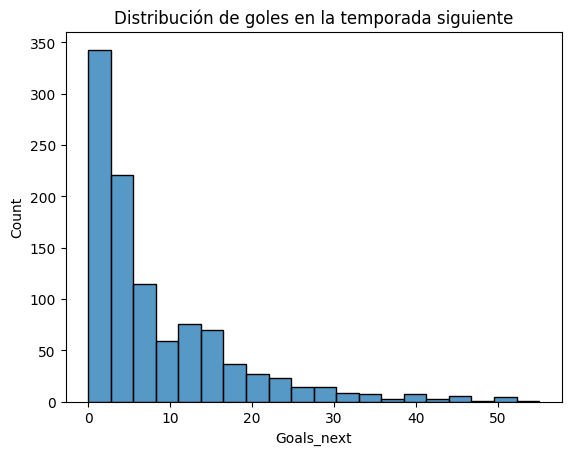

In [6]:
sns.histplot(df, x='Goals_next', bins=20)
plt.title('Distribución de goles en la temporada siguiente')
plt.show()

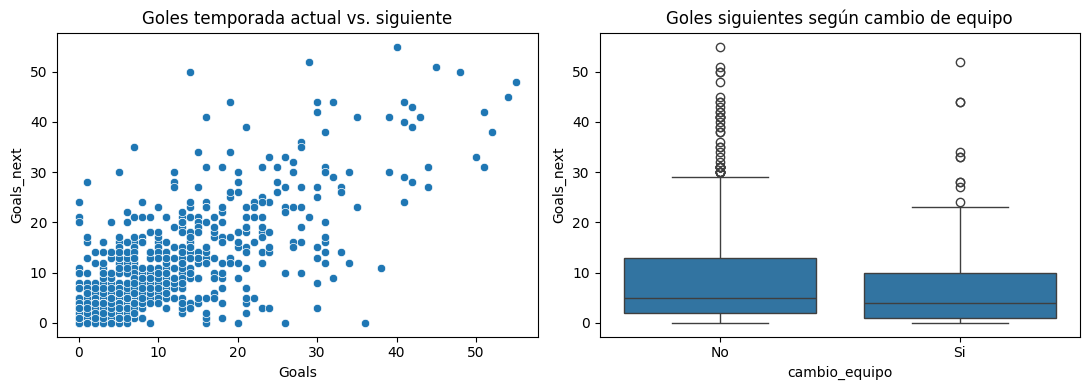

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(data=df, x='Goals', y='Goals_next', ax=ax[0])
ax[0].set_title('Goles temporada actual vs. siguiente')

sns.boxplot(data=df, x='cambio_equipo', y='Goals_next', ax=ax[1])
ax[1].set_title('Goles siguientes según cambio de equipo')
plt.tight_layout()
plt.show()

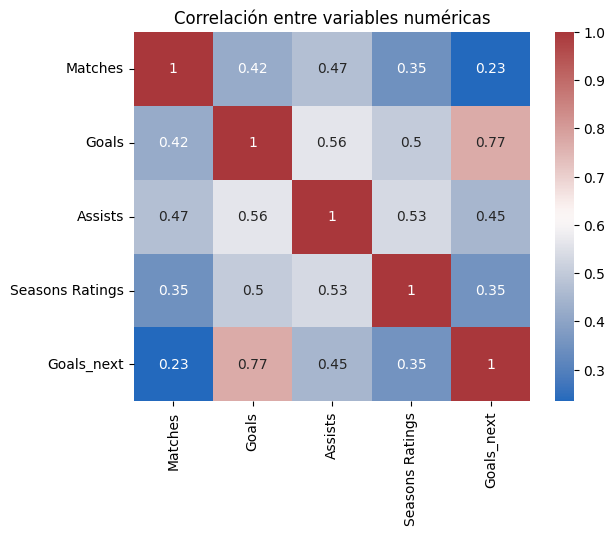

In [8]:
num = df[['Matches', 'Goals', 'Assists', 'Seasons Ratings', 'Goals_next']]
sns.heatmap(num.corr(), annot=True, cmap='vlag')
plt.title('Correlación entre variables numéricas')
plt.show()

**Hallazgos del EDA (numerados, con la gráfica que los respalda):**

1. **Distribución de `Goals_next` (histograma):** la distribución está fuertemente sesgada a la derecha: más de 340 pares (un tercio del dataset) tienen entre 0 y 3 goles en la temporada siguiente, y la frecuencia cae rápido a partir de ahí, con una cola larga y delgada que llega hasta 55. Confirma que la mayoría de los jugadores-temporada de este dataset son de gol moderado, y los verdaderos goleadores de 40+ son una minoría que domina el extremo de la distribución.

2. **`Goals` vs. `Goals_next` (scatter):** hay una tendencia positiva clara: los puntos suben de izquierda a derecha, y los jugadores con más de 30 goles en la temporada actual casi nunca caen por debajo de 20 en la siguiente. Pero la nube es ancha, no una línea: hay bastante dispersión sobre todo en la zona baja (0-15 goles), donde un jugador con pocos goles puede terminar con cualquier cosa entre 0 y 30 la siguiente temporada. Esto es coherente con el R² del modelo (~0.61): la relación es real y útil, pero está lejos de ser determinista.

3. **`Goals_next` según `cambio_equipo` (boxplot):** la diferencia es más sutil de lo que parecía en un principio: las medianas son casi idénticas (5 goles para quienes se quedan, 4 para quienes cambian de equipo), y las cajas (IQR) se solapan bastante. La diferencia real está en la cola alta: el grupo que se queda en el mismo equipo tiene muchos más outliers extremos (varios puntos por encima de 40, hasta 55), mientras que el grupo que cambia de equipo tiene outliers más escasos y moderados (tope cerca de 52, pero solo un par de casos). Es decir, cambiar de equipo no golpea al jugador "típico", pero sí parece coincidir con que las temporadas verdaderamente extraordinarias (40+ goles) casi siempre pasan cuando el jugador se queda en su club — probablemente porque una super-temporada rara vez coincide con salir vendido. Esto ultimo mencionado llevaría a pensar que rara vez un jugador del que "se decisieron" tendría una buenísima temporada.

4. **Correlación entre variables numéricas (heatmap):** `Goals` es, por lejos, la variable más correlacionada con `Goals_next` (0.77), muy por encima de `Assists` (0.45), `Seasons Ratings` (0.35) o `Matches` (0.23). Confirma numéricamente lo que ya se veía en el scatter: el nivel goleador actual es el mejor predictor disponible en este dataset, más que la cantidad de partidos jugados. Eso si, es curiosa la correlacion de `Assists` siendo más alta que las ultimas do mencionadas, considerando que son dos estadisticas diferentes que uno no pensaria tendría tanto que ver. 


## 6. Feature engineering

*Encodings, escalamiento y variables derivadas. Cada transformación necesita una frase que explique por qué existe.*

**Atención al leakage:** la partición train/test va **antes** de ajustar cualquier transformación.

In [9]:
from sklearn.model_selection import train_test_split

X = df[['Matches', 'Goals', 'Assists', 'Seasons Ratings', 'cambio_equipo']]
y = df['Goals_next']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape)

(830, 5) (208, 5)


In [10]:
# Transformaciones dentro de un Pipeline: fit solo con train
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preproceso = ColumnTransformer([
    ('num', StandardScaler(), ['Matches', 'Goals', 'Assists', 'Seasons Ratings']),
    ('cat', OneHotEncoder(), ['cambio_equipo']),
])

**Features y su justificación:**

| Feature | Cómo se construyó | Por qué debería ayudar |
|---|---|---|
| `Matches`, `Goals`, `Assists`, `Seasons Ratings` (escaladas) | Son las 4 columnas numéricas del dataset. Se les aplicó `StandardScaler` (resta la media y divide entre la desviación estándar), ajustado únicamente con `X_train` dentro del `ColumnTransformer`, para que el resultado en `X_test` no dependa de información que el modelo no debería conocer todavía | Estas variables tienen escalas muy distintas entre sí (partidos van de 1 a 59, rating va de 5.1 a 8.9); sin escalar, una regresión lineal terminaría dándole más peso a la variable con el rango numérico más grande simplemente por su magnitud, no porque sea más importante para predecir goles. Escalarlas pone a las 4 en la misma unidad, para que los coeficientes del modelo reflejen relevancia real y no solo tamaño de escala |
| `cambio_equipo` (one-hot) | Es una variable de texto con dos categorías ('Sí'/'No'), así que se transformó con `OneHotEncoder`, que crea una columna binaria (0 o 1) por cada categoría posible en vez de asignarle un número directo | Un modelo no puede operar matemáticamente sobre texto, así que codificarla es obligatorio para poder usarla. Se eligió one-hot y no un ordinal arbitrario (ej. 'No'=0, 'Sí'=1 tratado como escala) porque no existe un orden real entre ambas categorías — un ordinal le haría creer al modelo que 'Sí' es "más" que 'No' en algún sentido numérico, lo cual no tiene sentido aquí |



Ninguna transformación usa información de la temporada N+1 salvo `cambio_equipo`, que es dato conocido de antemano (no leakage): el `train_test_split` se hizo antes de ajustar el `StandardScaler`/`OneHotEncoder`, y ambos se ajustaron solo con `X_train`.

**Nota aclaratoria:** aunque las 5 columnas de `X` son "features", no todas se originaron igual. `Matches`, `Goals`, `Assists` y `Seasons Ratings` ya existían en el CSV original — lo único que se hizo con ellas fue transformarlas (escalarlas con `StandardScaler`) antes de dárselas al modelo, sin cambiar la información que representan. `cambio_equipo`, en cambio, no existía en ningún lado: se construyó comparando el equipo del jugador en la temporada actual (`Teams`) contra el de la temporada siguiente (`Team_next`, obtenido con `.shift(-1)`), generando una columna con información nueva que antes no estaba explícita. Por eso esta última necesita una justificación extra de por qué se creó (ver nota debajo de la tabla), mientras que las otras cuatro solo necesitan justificar el cómo se transformaron.


## 7. Modelo baseline

*Primero el baseline trivial (predecir la media o la clase mayoritaria), después el modelo propuesto. Sin el trivial, un número no significa nada.*

In [11]:
# Baseline trivial: DummyRegressor o DummyClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)

DummyRegressor()

In [12]:
# Modelo propuesto: regresión lineal, dentro del Pipeline
from sklearn.linear_model import LinearRegression

modelo = Pipeline([
    ('prep', preproceso),
    ('reg', LinearRegression())
])
modelo.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Matches', 'Goals',
                                                   'Assists',
                                                   'Seasons Ratings']),
                                                 ('cat', OneHotEncoder(),
                                                  ['cambio_equipo'])])),
                ('reg', LinearRegression())])

In [13]:
# Evaluación en test, con la métrica que corresponda al problema
# Regresión: RMSE, MAE, R2 · Clasificación: accuracy, precision, recall
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def metricas(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return pd.Series({'RMSE': rmse, 'MAE': mae, 'R2': r2})

pd.DataFrame({
    'Trivial (train)': metricas(y_train, dummy.predict(X_train)),
    'Trivial (test)': metricas(y_test, dummy.predict(X_test)),
    'Propuesto (train)': metricas(y_train, modelo.predict(X_train)),
    'Propuesto (test)': metricas(y_test, modelo.predict(X_test)),
})

,Trivial (train),Trivial (test),Propuesto (train),Propuesto (test)
RMSE,9.164168,9.879883,5.677300,6.167046
MAE,6.790791,7.321849,3.772730,4.191416
R2,0.000000,-0.006805,0.616207,0.607720


**Resultados(datos redondeados a dos decimales):**

| Modelo | RMSE train | RMSE test | R² train | R² test |
|---|---|---|---|---|
| Trivial | 9.16 | 9.88 | 0.00 | -0.01 |
| Propuesto (regresión lineal) | 5.68 | 6.17 | 0.62 | 0.61 |

*¿Le gana el modelo propuesto al trivial? ¿Por cuánto? ¿Vale la pena la complejidad extra?*

Sí, y por un margen amplio. El RMSE en test baja de 9.88 a 6.17 goles (una reducción de ~37%), el MAE baja de 7.32 a 4.19 goles (~43% menos error absoluto), y el R² pasa de 0.00 (el trivial, por definición, no explica nada de la varianza) a 0.61 en el modelo propuesto. En otras palabras: predecir usando las estadísticas de la temporada actual explica alrededor del 61% de la variación en los goles de la temporada siguiente, algo que el trivial no puede hacer por diseño.

Vale la pena la complejidad extra: pasar de "predecir siempre el promedio" a una regresión lineal con 5 variables es un salto mínimo en complejidad (sigue siendo un modelo simple, interpretable, sin tuning de hiperparámetros) a cambio de una mejora sustancial en la métrica. Además, el R² de train (0.62) y test (0.61) son casi idénticos, lo que confirma que esta mejora no es producto de sobreajuste — el modelo generaliza igual de bien a datos que no vio.

Dicho esto, un MAE de ~4.19 goles sigue siendo un margen de error considerable frente a una mediana de 5 goles por temporada en el dataset: el modelo es útil como *tendencia general* (le gana claramente a no tener modelo), pero está lejos de ser preciso jugador por jugador — justo lo que se espera de un baseline, no de un modelo final.


## 8. Conclusiones y límites

**Respuesta a la pregunta:** Sí es posible predecir, con un margen de error razonable, cuántos goles anotará un jugador de élite en su próxima temporada usando solo sus estadísticas de la temporada actual: el modelo explica ~61% de la varianza (frente a 0% del trivial). El predictor más fuerte es, sin sorpresa, la cantidad de goles ya anotados — el nivel goleador de un jugador de élite tiende a ser relativamente estable de una temporada a otra — y cambiar de equipo se asocia con una caída moderada en el rendimiento futuro. Aun así, el error típico del modelo (~4 goles) sigue siendo grande frente al rango habitual de goles por temporada (2 a 12 para la mayoría de los jugadores), así que es más una señal de tendencia general que una predicción precisa jugador por jugador.

**Límites del análisis:**

- La muestra son solo 165-167 jugadores, todos estrellas reconocidas de las 5 grandes ligas — el modelo no dice nada sobre cómo se comportaría un jugador promedio, un debutante, o alguien fuera de ese nivel.
- No hay variables de edad, posición ni minutos jugados: dos jugadores con los mismos goles y asistencias pero edades muy distintas (24 vs. 34 años, por ejemplo) probablemente tengan trayectorias futuras opuestas, y el modelo no puede distinguirlos.
- `cambio_equipo` es una bandera binaria muy simple: no distingue si el jugador fue a un equipo mejor o peor, ni a qué liga — mezclar todos los casos en un solo 'Sí/No' es una simplificación fuerte.
- Correlación no es causalidad: que `Goals_next` correlacione con `Goals` no prueba que "anotar mucho cause seguir anotando mucho"; es más razonable pensar que ambas variables reflejan un nivel de talento/rol relativamente estable en el jugador.
- El modelo no debería usarse fuera del perfil de jugadores que vio en entrenamiento (ligas menores, jugadores muy jóvenes, lesiones graves de por medio), porque nunca aprendió de casos así.

**Qué haría falta para responderla mejor:** edad exacta, posición, minutos jugados, historial de lesiones, nivel de la liga de destino en caso de transferencia, y una muestra más amplia y representativa que incluya jugadores de nivel medio, no solo superestrellas.


## 9. Bitácora de colaboración con AI

*Si existio asistencia del uso de herramientas de AI. Principalmente se utilizó e 3 aspectos. Primero se utilizo para facilitar la creación de las gráficas. Si se  entendía el concepto, solo se buscaba entender bien el orden y significado de cada linea de codigo para poder realizar la grafica de buena forma. Segundo, mejorar el estilo de las respuestas en Markdown. Esto principalmente a la hora de resaltar alguna variable o realizar alguna tabla comparativa, se dio a la IA el analisis hecho por la persona y resultados encontrados de forma algo desordenada, y la IA ayudo a que se viero mejor y se comprendiera de mejor forma. Por ultimo, se utilizo la IA para encontrar la informacion clave de las Hojas de Trabajo que podian aprovecharse durante este proyecto. NO fue tanto un, "haz esto en base a esto", sino mas bien un "Dónde puedo encontrar dentro de estos notebooks el código que más puede ayudarme a resolver este problema". Ya habiendo identificado el ejemplo ideal, se podia avanzar en la realizacion del código. Al final, la IA solo se uso para realizar retoques y resolver errores pequeños de una linea o una palabra*

## Anexo: peer critique (se llena en clase)

**Revisor:**

1. ¿Entendí la pregunta del proyecto sin preguntarle al autor?
2. ¿Hay alguna gráfica o celda que yo borraría? ¿Cuál y por qué?
3. ¿Veo algún punto donde se pudo haber colado información del test?